# Analysing `emle-analyze` output: energy decomposition for ChoM

In the [ADP example](ADP.ipynb) we briefly met `emle-analyze`, the tool that
quantifies how well an EMLE model reproduces a reference QM/MM calculation. There
we ran it on a single trajectory and printed three RMSE numbers. Here we go much
deeper, reproducing the error analysis from **Fig. 4** of
[Gradisteanu *et al.*, *Chem. Sci.* (2026)](https://pubs.rsc.org/sc/article/17/17/8542/1240667/Simulating-enzyme-catalysis-with-electrostatically)
for the **chorismate → prephenate** reaction catalysed by *E. coli* chorismate
mutase (**EcChoM**).

### The EMLE energy decomposition

The central idea behind EMLE is that the ML/MM energy of the QM (ML) region can
be split into three physically meaningful pieces:

$$ E_{\mathrm{ML/MM}} = E_{\mathrm{gas}} + E_{\mathrm{static}} + E_{\mathrm{induced}} $$

* $E_{\mathrm{gas}}$ - the energy of the ML region *in vacuo* (predicted by the
  gas-phase MLP; here a DeePMD model).
* $E_{\mathrm{static}}$ - the electrostatic interaction between the **unperturbed**
  ML charge density and the MM point charges (EMLE predicts MBIS atomic charges
  and valence-shell widths to evaluate this).
* $E_{\mathrm{induced}}$ - the extra energy from **polarising** the ML region in the
  MM field (EMLE predicts atomic polarisabilities for this).

Because the three terms are computed independently, we can isolate the error of
**each** component against a high-level DFT/MM reference and ask: *which one
limits the accuracy of the model, and why?*

### What we will do

`emle-analyze` was run on each of the **48 umbrella-sampling (US) windows** that
tile the reaction coordinate, producing one `.mat` file per window
(`ChoM_analyze/enzyme/1.mat` … `48.mat`). In this notebook we will:

1. **parse** a directory of `emle-analyze` `.mat` files,
2. **decompose** the ML(EMLE)/MM error into its gas / static / induced parts,
3. work out **which error dominates** and reason about its origin,
4. compare EMLE's predicted **MBIS charges** to the reference.

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

plt.rc('figure', facecolor='w')
plt.rc('font', size=11)

## 1. Parsing the `emle-analyze` output

Each `.mat` file holds the analysis of **one US window**: 500 sampled frames,
each with 24 QM atoms. The keys come in `*_qm` (the DFT reference) /
`*_emle` (the EMLE prediction) pairs. The most important ones:

| key | meaning |
|---|---|
| `z`, `xyz` | atomic numbers and coordinates (Å) of the QM atoms |
| `E_vac_qm` / `E_vac_emle` | **gas-phase** energy (DFT / MLP), kcal/mol |
| `E_static_qm` / `E_static_emle` | **static** embedding energy (DFT / EMLE) |
| `E_static_mbis` | static energy from EMLE's functional form fed the **exact** MBIS charges (more on this later) |
| `E_induced_qm` / `E_induced_emle` | **induced** (polarisation) energy (DFT / EMLE) |
| `q_core_qm`,`q_val_qm` / `q_core_emle`,`q_val_emle` | MBIS core & valence atomic charges; the total atomic charge is `q_core + q_val` |
| `s_qm` / `s_emle` | MBIS valence-shell widths |
| `alpha_qm` / `alpha_emle` | molecular polarisability tensor (3×3) |
| `atomic_alpha_emle` | per-atom isotropic polarisabilities |

Let's look at the raw contents of a single window.

In [2]:
raw = scipy.io.loadmat('ChoM_analyze/enzyme/1.mat', squeeze_me=True)
for k, v in sorted(raw.items()):
    if k.startswith('__'):
        continue
    print(f'{k:18s} shape={str(np.shape(v)):14s} dtype={np.asarray(v).dtype}')

E_induced_emle     shape=(500,)         dtype=float32
E_induced_qm       shape=(500,)         dtype=float64
E_static_emle      shape=(500,)         dtype=float32
E_static_mbis      shape=(500,)         dtype=float32
E_static_qm        shape=(500,)         dtype=float64
E_vac_emle         shape=(500,)         dtype=float64
E_vac_qm           shape=(500,)         dtype=float64
alpha_emle         shape=(500, 3, 3)    dtype=float32
alpha_qm           shape=(500, 3, 3)    dtype=float64
atomic_alpha_emle  shape=(500, 24)      dtype=float32
q_core_emle        shape=(500, 24)      dtype=float32
q_core_qm          shape=(500, 24)      dtype=float64
q_val_emle         shape=(500, 24)      dtype=float32
q_val_qm           shape=(500, 24)      dtype=float64
s_emle             shape=(500, 24)      dtype=float32
s_qm               shape=(500, 24)      dtype=float64
xyz                shape=(500, 24, 3)   dtype=float64
z                  shape=(500, 24)      dtype=int64


### Loading all 48 windows at once

`scipy.io.loadmat` returns a dict that also contains MATLAB bookkeeping keys
(`__header__`, …); `read_data` strips those. `merge_dicts` then stacks the 48
per-window arrays so that, e.g., `enzyme_data['E_static_qm']` has shape
`(48, 500)` - one row per window. These two helpers are all you need to turn a
directory of `emle-analyze` outputs into convenient NumPy arrays.

In [3]:
def read_data(filename):
    data = scipy.io.loadmat(filename, squeeze_me=True)
    return {k: v for k, v in data.items() if hasattr(v, 'shape')}


def merge_dicts(list_of_dicts):
    keys = list_of_dicts[0].keys()
    return {k: np.array([d[k] for d in list_of_dicts]) for k in keys}


enzyme_data = merge_dicts([read_data(f'ChoM_analyze/enzyme/{i}.mat')
                           for i in range(1, 49)])

print('windows x frames:', enzyme_data['E_static_qm'].shape)
print('QM atoms        :', enzyme_data['z'].shape[-1])

windows x frames: (48, 500)
QM atoms        : 24


## 2. The reaction coordinate

The chorismate → prephenate Claisen rearrangement breaks a C-O bond and forms a
C-C bond. We follow it with an antisymmetric reaction coordinate (RC):

$$ \mathrm{RC} = d(\mathrm{C}_5\!-\!\mathrm{O}_7) - d(\mathrm{C}_0\!-\!\mathrm{C}_9) $$

(0-based atom indices into the QM region). Negative RC = reactant
(chorismate, C-O bond intact); positive RC = product (prephenate, new C-C bond
formed). `get_rc` works directly on the stacked `xyz` array.

In [4]:
def get_rc(xyz):
    d_breaking = np.linalg.norm(xyz[:, :, 5] - xyz[:, :, 7], axis=-1)  # C-O
    d_forming  = np.linalg.norm(xyz[:, :, 0] - xyz[:, :, 9], axis=-1)  # C-C
    return d_breaking - d_forming


enzyme_data['rc'] = get_rc(enzyme_data['xyz'])

# Bins along the RC, used later to average errors as a function of progress.
enzyme_data['bins'] = np.arange(-2.6, 2.4 + 0.001, 0.05)

print(f"RC range sampled: {enzyme_data['rc'].min():.2f} .. {enzyme_data['rc'].max():.2f} A")

RC range sampled: -2.63 .. 2.44 A


## 3. Context: the free-energy profile

Before dissecting the errors, it helps to see what we are ultimately after: the
**potential of mean force** (PMF) along the RC. The PMF is *not* produced by
`emle-analyze` (it comes from WHAM/umbrella integration over the US windows); we
just load the pre-computed curves to set the stage. We compare the **DFT/MM**
reference with **ML(EMLE)/MM**.

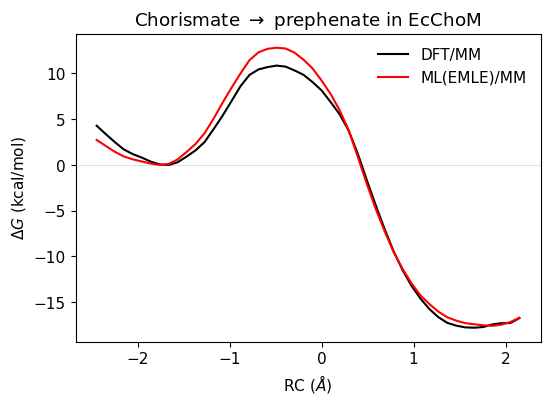

In [5]:
def read_pmf(method):
    rc, g = np.loadtxt(f'ChoM_analyze/PMF/pmf_enzyme_{method}.dat').T
    # Reference each profile to its reactant-state minimum (negative-RC half).
    return rc, g - np.min(g[:len(rc) // 2])


fig, ax = plt.subplots(figsize=(6, 4))
for method, color, label in [('dft', 'black', 'DFT/MM'),
                             ('emle', 'red', 'ML(EMLE)/MM')]:
    rc, g = read_pmf(method)
    ax.plot(rc, g, color=color, label=label)
ax.axhline(0, color='lightgrey', lw=0.5, zorder=-1)
ax.set_xlabel(r'RC ($\AA$)')
ax.set_ylabel(r'$\Delta G$ (kcal/mol)')
ax.set_title(r'Chorismate $\to$ prephenate in EcChoM')
ax.legend(frameon=False)
plt.show()

The two profiles are close: the EMLE model reproduces both the reaction barrier
and the overall reaction free energy, with the barrier slightly
**over**estimated. To understand *where* that residual disagreement comes from,
we decompose the error.

## 4. Decomposing the error

For every frame we define the error of each energy component as

$$ \varepsilon_X = E_X^{\mathrm{EMLE}} - E_X^{\mathrm{QM}}, \qquad X \in \{\text{gas, static, induced}\} $$

and the total error is simply their sum,
$\varepsilon_{\mathrm{tot}} = \varepsilon_{\text{gas}} + \varepsilon_{\text{static}} + \varepsilon_{\text{induced}}$.
Each window samples a range of RC values, so averaging the error per window would
blur how it depends on the RC. Instead we pool all frames and average them
**within narrow RC bins** using the `get_by_rc` function below.

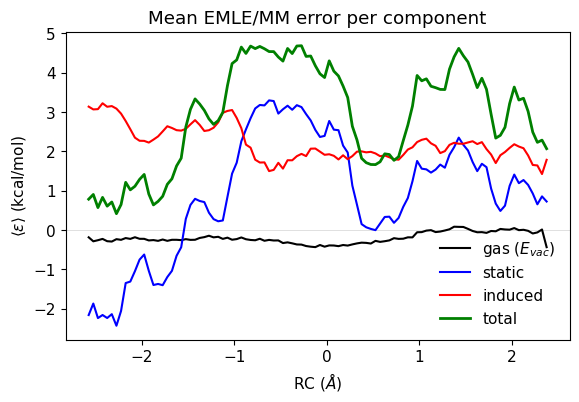

In [6]:
def get_by_rc(rc, values, bins):
    counts, edges = np.histogram(rc, bins=bins)
    centers = (edges[1:] + edges[:-1]) / 2
    bin_idx = ((rc - edges[0]) // (edges[1] - edges[0])).astype(int)
    mean = np.array([np.mean(values[bin_idx == i]) for i in range(len(counts))])
    return centers, mean


rc   = enzyme_data['rc']
bins = enzyme_data['bins']

err_gas     = enzyme_data['E_vac_emle']     - enzyme_data['E_vac_qm']
err_static  = enzyme_data['E_static_emle']  - enzyme_data['E_static_qm']
err_induced = enzyme_data['E_induced_emle'] - enzyme_data['E_induced_qm']
err_total   = err_gas + err_static + err_induced

x, gas_m     = get_by_rc(rc, err_gas,     bins)
x, static_m  = get_by_rc(rc, err_static,  bins)
x, induced_m = get_by_rc(rc, err_induced, bins)
x, total_m   = get_by_rc(rc, err_total,   bins)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(x, gas_m,     color='black',  label=r'gas ($E_{vac}$)')
ax.plot(x, static_m,  color='blue', label='static')
ax.plot(x, induced_m, color='red', label='induced')
ax.plot(x, total_m,   color='green', lw=2, label='total')
ax.axhline(0, color='lightgrey', lw=0.5, zorder=-1)
ax.set_xlabel(r'RC ($\AA$)')
ax.set_ylabel(r'$\langle \varepsilon \rangle$ (kcal/mol)')
ax.set_title('Mean EMLE/MM error per component')
ax.legend(frameon=False)
plt.show()

## 5. Which error dominates?

Reading the plot:

* **Gas ($E_{\mathrm{vac}}$)** error is essentially **zero** across the whole RC -
  the DeePMD MLP describes the in-vacuo reaction faithfully.
* **Induced** error is **systematically positive but nearly flat** - a roughly
  constant offset of $\sim\!2$ kcal/mol. EMLE slightly *under*-binds because
  QM/MM tends to *over*-estimate interactions for anionic regions (charge
  spill-over onto positive MM charges), an artifact a gas-trained model like EMLE
  does not suffer from.
* **Static** error is the one that **varies most along the RC** and the **total**
  error tracks it closely.

What matters for the *free-energy profile* is not
the absolute error of a component but how that error **changes along the RC**: a
constant offset shifts every window equally and therefore **cancels** in
barriers and reaction energies. So a useful way to read the errors is to split
each into its **systematic** part (the mean) and its **spread**. The component
whose error *spreads* the most is the one that distorts the PMF shape.

In [7]:
def get_rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


d = enzyme_data
components = {
    'gas  (E_vac)': (d['E_vac_emle'],     d['E_vac_qm']),
    'static':       (d['E_static_emle'],  d['E_static_qm']),
    'induced':      (d['E_induced_emle'], d['E_induced_qm']),
    'total':        (d['E_vac_emle']  + d['E_static_emle']  + d['E_induced_emle'],
                     d['E_vac_qm']    + d['E_static_qm']    + d['E_induced_qm']),
}
print(f"{'component':14s}{'mean err':>10s}{'spread (std)':>14s}   (kcal/mol)")
print('-' * 48)
for name, (a, b) in components.items():
    err = a - b
    print(f'{name:14s}{err.mean():10.3f}{err.std():14.3f}')

component       mean err  spread (std)   (kcal/mol)
------------------------------------------------
gas  (E_vac)      -0.188         0.353
static             0.772         2.331
induced            2.248         0.778
total              2.832         2.387


The **induced** error has a *large mean but a small spread* - it is mostly
that constant offset.
The **static** error has by far the **largest spread**, i.e. it is the component
that genuinely shapes the error in the free-energy profile. In this sense the
**static component dominates the error** for the enzyme reaction.

## 6. Is the static error a *charge-prediction* problem?

The static energy depends on the ML region's atomic charges (and widths), which
EMLE *predicts*. A natural question: is the static error because EMLE predicts
**bad charges**, or because of the **functional form** itself (representing the
density by atomic monopoles only, ignoring dipoles, quadrupoles, …)?

`emle-analyze` lets us separate these. The key `E_static_mbis` is the static
energy computed with the **same EMLE functional form** but fed the **exact MBIS
charges and widths** from the DFT reference instead of the predicted ones. It is
therefore the best the monopole functional form could possibly do - a "perfect
charge model". If the static error were due to bad charges, `E_static_mbis`
should be much closer to the reference than `E_static_emle`.

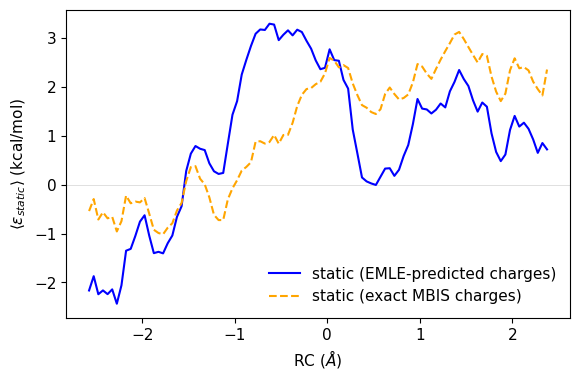

static RMSE, EMLE charges : 2.456
static RMSE, exact MBIS   : 2.198


In [8]:
err_static_mbis = enzyme_data['E_static_mbis'] - enzyme_data['E_static_qm']
x, static_mbis_m = get_by_rc(rc, err_static_mbis, bins)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(x, static_m,      color='blue',   label='static (EMLE-predicted charges)')
ax.plot(x, static_mbis_m, color='orange', ls='--', label='static (exact MBIS charges)')
ax.axhline(0, color='lightgrey', lw=0.5, zorder=-1)
ax.set_xlabel(r'RC ($\AA$)')
ax.set_ylabel(r'$\langle \varepsilon_{static} \rangle$ (kcal/mol)')
ax.legend(frameon=False)
plt.show()

print(f"static RMSE, EMLE charges : {get_rmse(d['E_static_emle'], d['E_static_qm']):.3f}")
print(f"static RMSE, exact MBIS   : {get_rmse(d['E_static_mbis'], d['E_static_qm']):.3f}")

Feeding the **exact** MBIS charges does reduce the static error, and in a way
that matters for the PMF: around the transition state (RC $\approx 0$) the error
comes down, so the **reactant→TS variation** of the error shrinks - notice how
the orange curve is flatter than the blue one between RC $\approx -2$ and $0$. So
more accurate charges *are* relevant and would help.

They are not the whole story, though. The overall RMSE drops only modestly
(printed above) and a substantial, RC-dependent error still remains even with
perfect charges. That residual reflects the **functional form** itself - the
density is represented by atomic monopoles only - and closing it would require
going beyond monopoles to higher atomic multipoles (dipoles, quadrupoles, …).

So how accurate are EMLE's predicted charges to begin with? Let's look.

## 7. Comparing MBIS charges

The total MBIS atomic charge is `q = q_core + q_val`. We compare EMLE's
prediction against the DFT reference for every atom in every frame, coloured by
element.

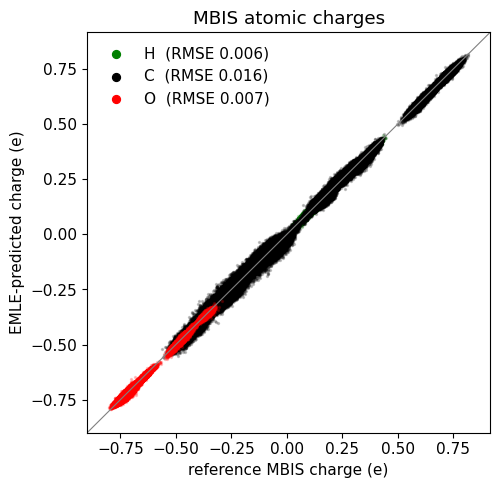

overall charge RMSE: 0.0116 e


In [9]:
q_emle = enzyme_data['q_core_emle'] + enzyme_data['q_val_emle']
q_qm   = enzyme_data['q_core_qm']   + enzyme_data['q_val_qm']
z      = enzyme_data['z']

# Flatten over windows, frames and atoms.
qe, qq, zz = q_emle.ravel(), q_qm.ravel(), z.ravel()

elements = {1: ('H', 'green'), 6: ('C', 'black'), 8: ('O', 'red')}

fig, ax = plt.subplots(figsize=(5.2, 5.2))
for Z, (sym, color) in elements.items():
    m = zz == Z
    ax.scatter(qq[m], qe[m], s=2, alpha=0.2, color=color,
               label=f'{sym}  (RMSE {get_rmse(qe[m], qq[m]):.3f})')
lims = [qq.min() - 0.1, qq.max() + 0.1]
ax.plot(lims, lims, color='grey', lw=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('reference MBIS charge (e)')
ax.set_ylabel('EMLE-predicted charge (e)')
ax.set_title('MBIS atomic charges')
leg = ax.legend(frameon=False, markerscale=4, loc='upper left')
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.show()

print(f'overall charge RMSE: {get_rmse(qe, qq):.4f} e')

The points sit tightly on the diagonal (overall RMSE well below $0.02\,e$): EMLE
already reproduces the reference charges very accurately across all elements,
including their wide variation during bond breaking/forming. The small charge
errors that remain are what the exact-MBIS test recovered above - a real but
modest part of the static error. The larger, RC-dependent remainder lies beyond
the reach of any monopole model.

### Tracking the most variable charge along the RC

The most chemically interesting charges are those that **change** during the
reaction. We rank the atoms by the standard deviation of their charge across all
frames and follow the top one. It turns out to be the **carbon of the breaking
C-O bond** (`C5`) - the atom most directly involved in the chemistry.

atom  element  charge std (e)
  5      C       0.201
  8      C       0.102
  6      C       0.091
  9      C       0.068
  7      O       0.057


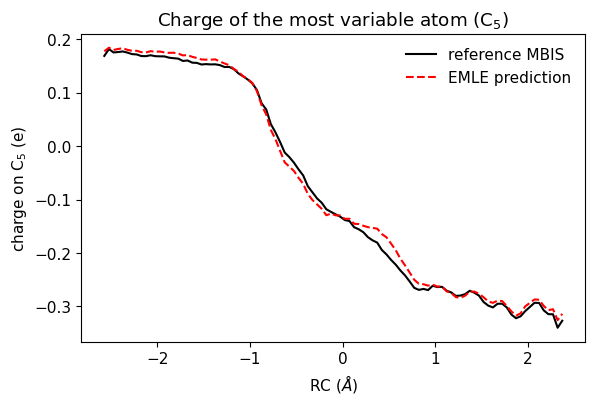

In [10]:
std_per_atom = q_qm.reshape(-1, q_qm.shape[-1]).std(axis=0)
order = np.argsort(std_per_atom)[::-1]
sym = {1: 'H', 6: 'C', 8: 'O'}
print('atom  element  charge std (e)')
for a in order[:5]:
    print(f'{a:3d}     {sym[z[0, 0, a]]:^3s}      {std_per_atom[a]:.3f}')

# Follow the top-ranked atom: the carbon of the breaking C-O bond.
atom = order[0]
label_atom = f'{sym[z[0, 0, atom]]}$_{{{atom}}}$'
x, q_qm_a   = get_by_rc(rc, q_qm[:, :, atom],   bins)
x, q_emle_a = get_by_rc(rc, q_emle[:, :, atom], bins)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(x, q_qm_a,   color='black', label='reference MBIS')
ax.plot(x, q_emle_a, color='red',   ls='--', label='EMLE prediction')
ax.set_xlabel(r'RC ($\AA$)')
ax.set_ylabel(rf'charge on {label_atom} (e)')
ax.set_title(rf'Charge of the most variable atom ({label_atom})')
ax.legend(frameon=False)
plt.show()

This carbon is part of the C-O bond that breaks during the reaction, and its
charge changes markedly: from clearly **positive** ($\sim\!+0.17\,e$, the
electron-poor ether carbon) in the reactant to **negative** ($\sim\!-0.33\,e$) in
the product. EMLE reproduces this large swing closely over the whole reaction
coordinate - a concrete illustration that the model captures the charge response
of a key reacting atom, not just the static averages.

## Summary

From a set of `emle-analyze` outputs, we:

1. **parsed** the per-window outputs into stacked NumPy arrays (`read_data` +
   `merge_dicts`);
2. **decomposed** the ML(EMLE)/MM error into gas, static and induced
   components and averaged them along the reaction coordinate;
3. found the **gas error ≈ 0** (good MLP), the **induced error a nearly
   constant positive offset** (a QM/MM reference artifact that cancels in the
   PMF, not an EMLE failure), and the **static error dominant in its variation
   along the RC** - i.e. the part that actually shapes the free-energy error;
4. showed, via `E_static_mbis`, that more accurate charges *would* reduce the
   static error - appreciably between reactant and TS - but **not eliminate it**;
   the larger remainder is a **functional-form** limit (atomic monopoles) that
   higher multipoles would address. EMLE's predicted charges are themselves
   already accurate, including the charge swing on the reacting oxygen.

The take-home for model development: for this enzyme reaction the EMLE model is
already accurate enough for free-energy work, and the path to further improvement
runs **mainly through higher atomic multipoles** in the static term, with smaller
additional gains available from even more accurate charges.